In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load dataset
df = pd.read_csv("lung_cancer.csv")

# check dataset size
print("Rows, Columns:", df.shape)

# see first 5 rows
df.head()


Rows, Columns: (5000, 30)


,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


In [2]:
# basic dataset info (columns, data types, missing counts)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  prev

In [3]:
# check missing values column-wise
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing[missing > 0])




Missing values in each column:
Series([], dtype: int64)


In [4]:
# check duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)


Duplicate rows: 0


In [5]:
# cleaning column names (remove extra spaces and standardize format)

df.columns = df.columns.str.strip()      # remove leading/trailing spaces
df.columns = df.columns.str.lower()      # convert to lowercase
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with underscore

# check updated column names
print("Updated columns:")
print(df.columns.tolist())


Updated columns:
['age', 'gender', 'education_years', 'income_level', 'smoker', 'smoking_years', 'cigarettes_per_day', 'pack_years', 'passive_smoking', 'air_pollution_index', 'occupational_exposure', 'radon_exposure', 'family_history_cancer', 'copd', 'asthma', 'previous_tb', 'chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'bmi', 'oxygen_saturation', 'fev1_x10', 'crp_level', 'xray_abnormal', 'exercise_hours_per_week', 'diet_quality', 'alcohol_units_per_week', 'healthcare_access', 'lung_cancer_risk']


In [6]:
# dropping less useful / redundant columns

columns_to_drop = ["smoking_years", "cigarettes_per_day"]

df = df.drop(columns=columns_to_drop)

print("Shape after dropping columns:", df.shape)


Shape after dropping columns: (5000, 28)


In [7]:
# basic statistical summary of all numerical columns

df.describe()


,age,gender,education_years,income_level,smoker,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,6.249000,0.347600,64.278800,0.250800,0.144800,...,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,9.964901,0.476256,19.479809,0.433517,0.351934,...,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,...,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,51.000000,0.000000,0.000000,...,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.000000,...,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,10.000000,1.000000,78.000000,1.000000,0.000000,...,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,60.000000,1.000000,130.000000,1.000000,1.000000,...,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


In [8]:
# checking distribution of target variable

print("Target Counts:")
print(df["lung_cancer_risk"].value_counts())

print("\nTarget Percentage:")
print(df["lung_cancer_risk"].value_counts(normalize=True) * 100)


Target Counts:
lung_cancer_risk
0    3756
1    1244
Name: count, dtype: int64

Target Percentage:
lung_cancer_risk
0    75.12
1    24.88
Name: proportion, dtype: float64


In [9]:
# comparing average values for cancer risk vs no risk

grouped_mean = df.groupby("lung_cancer_risk").mean()

grouped_mean


,age,gender,education_years,income_level,smoker,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,...,fatigue,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access
lung_cancer_risk,,,,,,,,,,,,,,,,,,,,,
0,53.992812,0.481097,11.531683,2.556443,0.274228,1.485623,0.338658,63.717519,0.247870,0.135250,...,0.399894,23.658946,97.593983,33.837061,2.198349,0.028754,2.626731,2.538871,5.849042,2.547923
1,56.298232,0.509646,11.446141,2.548232,1.000000,20.631029,0.374598,65.973473,0.259646,0.173633,...,0.394695,23.441318,91.545820,24.346463,11.825563,0.722669,2.440514,2.522508,5.993569,2.503215


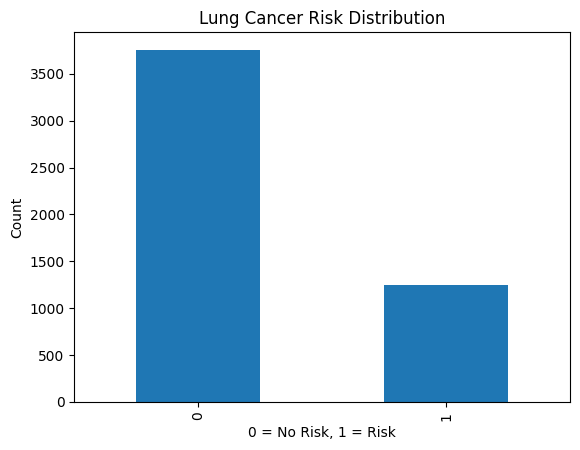

In [10]:
import matplotlib.pyplot as plt

# bar plot for target distribution

plt.figure()
df["lung_cancer_risk"].value_counts().plot(kind="bar")

plt.title("Lung Cancer Risk Distribution")
plt.xlabel("0 = No Risk, 1 = Risk")
plt.ylabel("Count")
plt.show()


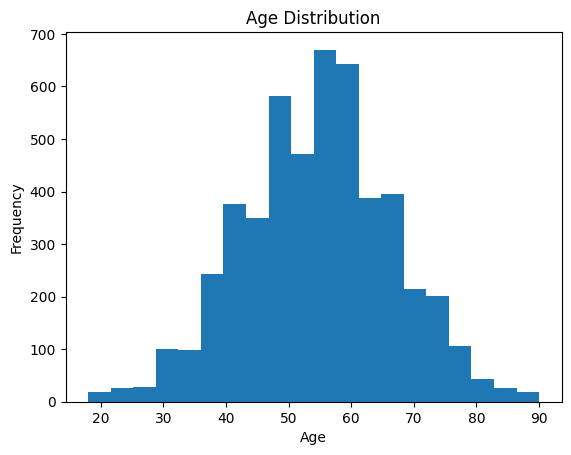

In [11]:
# plotting histogram to see how age is distributed

plt.figure()
plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


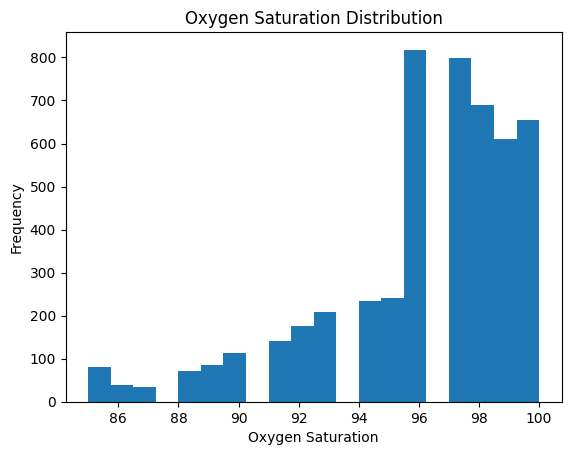

In [12]:
# checking distribution of oxygen saturation levels

plt.figure()
plt.hist(df["oxygen_saturation"], bins=20)

plt.title("Oxygen Saturation Distribution")
plt.xlabel("Oxygen Saturation")
plt.ylabel("Frequency")

plt.show()


In [13]:
# calculating correlation with target variable

corr = df.corr(numeric_only=True)["lung_cancer_risk"]

# sorting values in descending order
corr_sorted = corr.sort_values(ascending=False)

# selecting top 10 (excluding the target itself)
top_10 = corr_sorted[1:11]

print("Top 10 Features Correlated with Lung Cancer Risk:")
print(top_10)


Top 10 Features Correlated with Lung Cancer Risk:
pack_years               0.830688
crp_level                0.780422
xray_abnormal            0.748023
shortness_of_breath      0.659022
smoker                   0.630108
chronic_cough            0.629583
copd                     0.616377
age                      0.083533
family_history_cancer    0.063177
air_pollution_index      0.050072
Name: lung_cancer_risk, dtype: float64


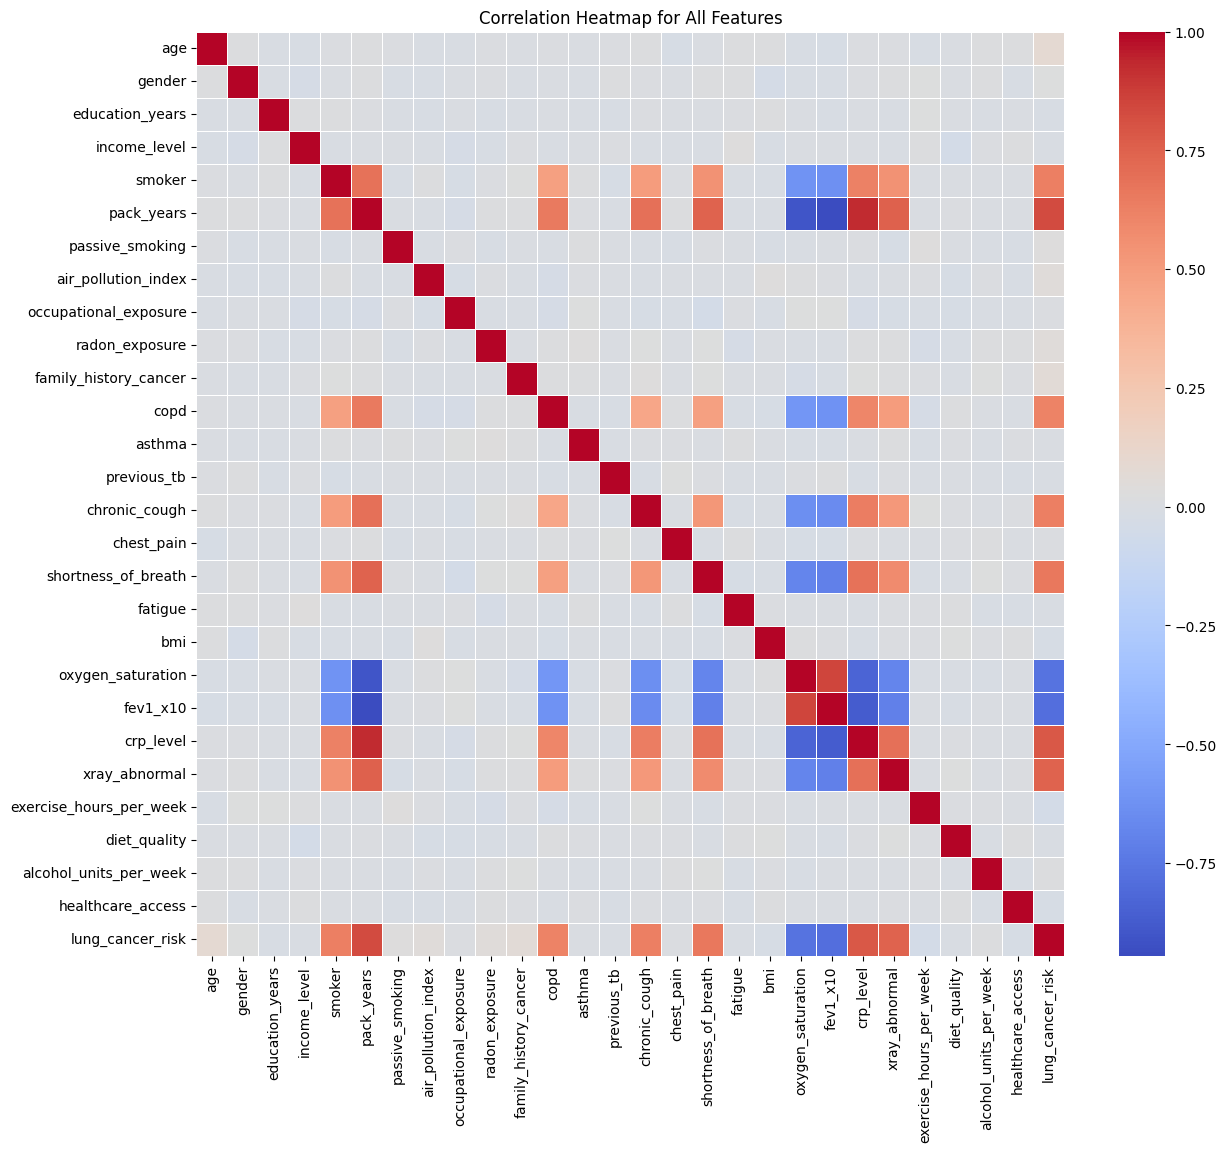

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute correlation matrix for all numeric columns
corr_matrix = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap for All Features")
plt.show()



<Figure size 640x480 with 0 Axes>

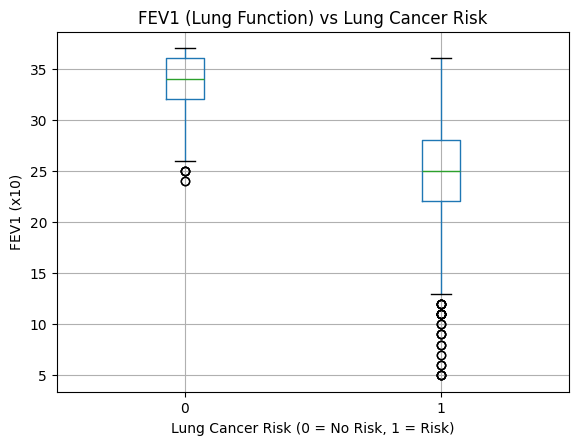

In [15]:
import matplotlib.pyplot as plt

# comparing lung function between people with and without cancer risk

plt.figure()

df.boxplot(column="fev1_x10", by="lung_cancer_risk")

plt.title("FEV1 (Lung Function) vs Lung Cancer Risk")
plt.suptitle("")   # removes automatic pandas title
plt.xlabel("Lung Cancer Risk (0 = No Risk, 1 = Risk)")
plt.ylabel("FEV1 (x10)")

plt.show()


In [16]:
from sklearn.model_selection import train_test_split

# -------------------------------------------------------
# Remove potential data leakage features
# These variables represent diagnostic tests or symptoms
# that typically appear AFTER the disease has developed.
# Our goal is to predict lung cancer risk using only
# pre-diagnosis risk factors.
#
# Examples:
# - xray_abnormal → result of medical imaging
# - crp_level → blood inflammation marker
# - oxygen_saturation → clinical measurement
# - shortness_of_breath / chronic_cough → symptoms
# - copd → existing lung disease diagnosis
#
# Including these would allow the model to indirectly
# detect existing cancer rather than predict risk.
# -------------------------------------------------------

leakage_columns = [
    "xray_abnormal",
    "crp_level",
    "oxygen_saturation",
    "fev1_x10",
    "shortness_of_breath",
    "chronic_cough",
    "copd"
]

# Drop leakage columns if present
df_model = df.drop(columns=leakage_columns, errors="ignore")

# separating features and target
X = df_model.drop("lung_cancer_risk", axis=1)
y = df_model["lung_cancer_risk"]

# performing stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)
print("Removed leakage columns:", leakage_columns)

Train shape: (4000, 20) (4000,)
Test shape : (1000, 20) (1000,)
Removed leakage columns: ['xray_abnormal', 'crp_level', 'oxygen_saturation', 'fev1_x10', 'shortness_of_breath', 'chronic_cough', 'copd']


In [17]:
from sklearn.preprocessing import StandardScaler

# creating scaler object
scaler = StandardScaler()

# fitting only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transforming test data
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)


Scaled train shape: (4000, 20)
Scaled test shape : (1000, 20)


In [18]:
from imblearn.over_sampling import SMOTE

# applying SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE :", pd.Series(y_train_smote).value_counts())


Before SMOTE: lung_cancer_risk
0    3005
1     995
Name: count, dtype: int64
After SMOTE : lung_cancer_risk
0    3005
1    3005
Name: count, dtype: int64


In [19]:
print("Final Training Shape:", X_train_smote.shape, y_train_smote.shape)
print("Final Testing Shape :", X_test_scaled.shape, y_test.shape)


Final Training Shape: (6010, 20) (6010,)
Final Testing Shape : (1000, 20) (1000,)


# Decison Tree Model base model and hyper parameter

In [20]:
from sklearn.tree import DecisionTreeClassifier

# creating decision tree model
dt_model = DecisionTreeClassifier(random_state=42)

# training model
dt_model.fit(X_train_smote, y_train_smote)

print("Decision Tree model trained successfully")


Decision Tree model trained successfully


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.935

Confusion Matrix:
 [[725  26]
 [ 39 210]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       751
           1       0.89      0.84      0.87       249

    accuracy                           0.94      1000
   macro avg       0.92      0.90      0.91      1000
weighted avg       0.93      0.94      0.93      1000



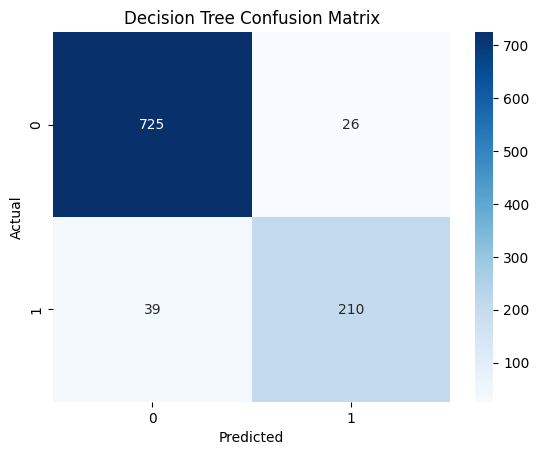

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# getting confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier

# pipeline: scale -> SMOTE -> model
dt_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# parameters to tune
dt_params = {
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

# grid search (ROC-AUC is good for imbalanced data)
dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best CV ROC-AUC:", dt_grid.best_score_)



Best Decision Tree Params: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV ROC-AUC: 0.9856244617429912


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

best_dt = dt_grid.best_estimator_

# predictions on test
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Test ROC-AUC :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Test Accuracy: 0.948
Decision Tree Test ROC-AUC : 0.983315418799031

Confusion Matrix:
 [[720  31]
 [ 21 228]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       751
           1       0.88      0.92      0.90       249

    accuracy                           0.95      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.95      0.95      0.95      1000



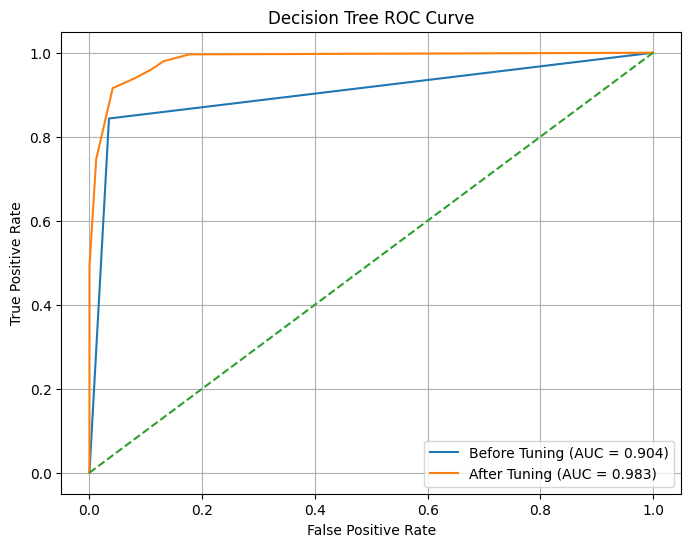

In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# base model probabilities
y_prob_dt_before = dt_model.predict_proba(X_test_scaled)[:, 1]

# tuned model
dt_best_model = dt_grid.best_estimator_
y_prob_dt_after = dt_best_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_dt_before)
roc_auc_before = auc(fpr_before, tpr_before)

fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_dt_after)
roc_auc_after = auc(fpr_after, tpr_after)

# plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Before Tuning (AUC = {roc_auc_before:.3f})")
plt.plot(fpr_after, tpr_after, label=f"After Tuning (AUC = {roc_auc_after:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Support Vector Model Both base Model and Hyperparameter

In [25]:
from sklearn.svm import SVC

# creating SVM model
svm_model = SVC(kernel="rbf", random_state=42)

# training
svm_model.fit(X_train_smote, y_train_smote)

print("SVM model trained successfully")


SVM model trained successfully


In [26]:
# predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.957

Confusion Matrix:
 [[725  26]
 [ 17 232]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       751
           1       0.90      0.93      0.92       249

    accuracy                           0.96      1000
   macro avg       0.94      0.95      0.94      1000
weighted avg       0.96      0.96      0.96      1000



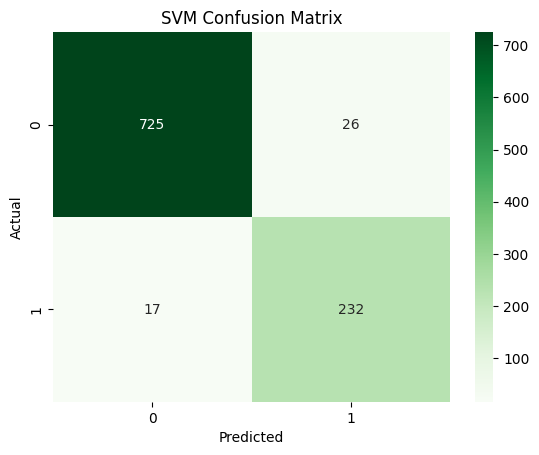

In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [28]:
from sklearn.svm import SVC

# pipeline: scale -> SMOTE -> model
svm_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(probability=True, random_state=42))
])

# parameters to tune
svm_params = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    svm_pipe,
    svm_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best CV ROC-AUC:", svm_grid.best_score_)


Best SVM Params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV ROC-AUC: 0.994464836662514


In [29]:
best_svm = svm_grid.best_estimator_

# predictions on test
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Test ROC-AUC :", roc_auc_score(y_test, y_prob_svm))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Test Accuracy: 0.96
SVM Test ROC-AUC : 0.9944063871999316

Confusion Matrix:
 [[722  29]
 [ 11 238]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       751
           1       0.89      0.96      0.92       249

    accuracy                           0.96      1000
   macro avg       0.94      0.96      0.95      1000
weighted avg       0.96      0.96      0.96      1000



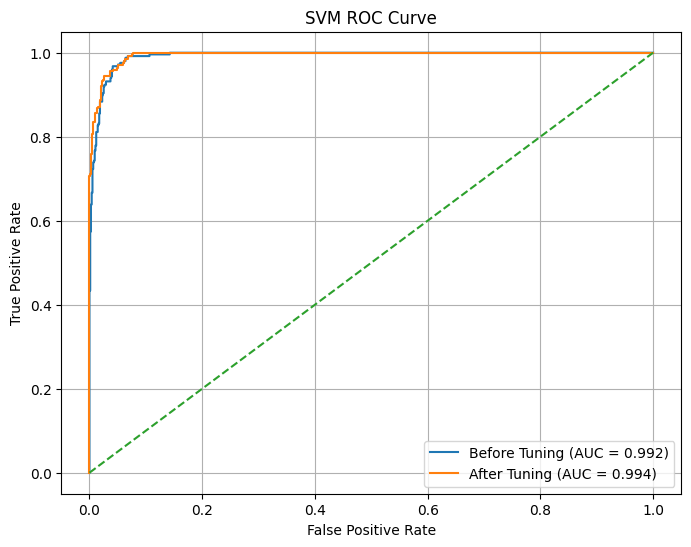

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# base model probabilities
svm_model_prob = SVC(kernel="rbf", probability=True, random_state=42)
svm_model_prob.fit(X_train_smote, y_train_smote)
y_prob_svm_before = svm_model_prob.predict_proba(X_test_scaled)[:, 1]

# tuned model
svm_best_model = svm_grid.best_estimator_
y_prob_svm_after = svm_best_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_svm_before)
roc_auc_before = auc(fpr_before, tpr_before)

fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_svm_after)
roc_auc_after = auc(fpr_after, tpr_after)

# plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Before Tuning (AUC = {roc_auc_before:.3f})")
plt.plot(fpr_after, tpr_after, label=f"After Tuning (AUC = {roc_auc_after:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# XgBoost base model and hyperparameter tuning

In [30]:
from xgboost import XGBClassifier

# creating xgboost model
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# training model
xgb_model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully")


XGBoost model trained successfully


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:37:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
# predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.957

Confusion Matrix:
 [[730  21]
 [ 22 227]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       751
           1       0.92      0.91      0.91       249

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000



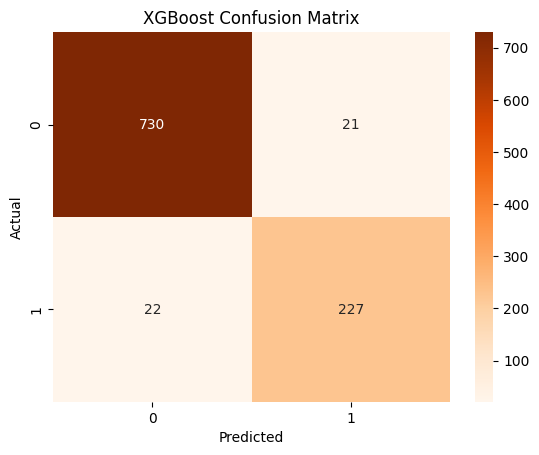

In [32]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [33]:
from xgboost import XGBClassifier

# pipeline: scale -> SMOTE -> model
xgb_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# parameters to tune
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", xgb_grid.best_score_)


Best XGBoost Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC-AUC: 0.9932039565548207


In [34]:
best_xgb = xgb_grid.best_estimator_

# predictions on test
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Test ROC-AUC :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Test Accuracy: 0.955
XGBoost Test ROC-AUC : 0.9921069096626185

Confusion Matrix:
 [[723  28]
 [ 17 232]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       751
           1       0.89      0.93      0.91       249

    accuracy                           0.95      1000
   macro avg       0.93      0.95      0.94      1000
weighted avg       0.96      0.95      0.96      1000



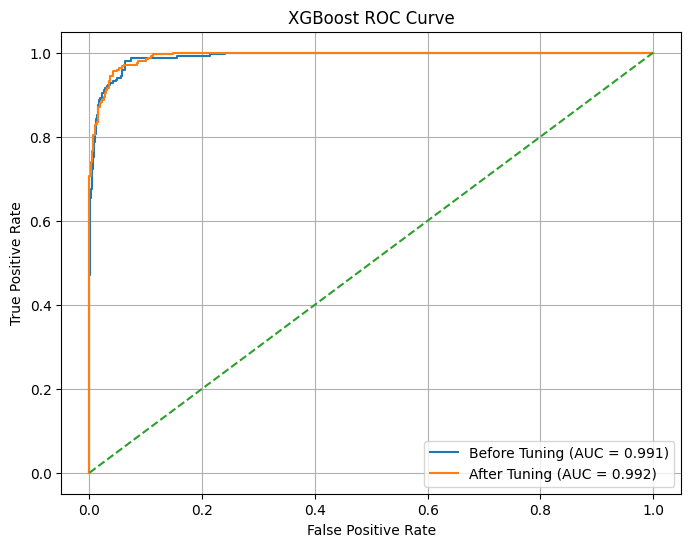

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# base model probabilities
y_prob_xgb_before = xgb_model.predict_proba(X_test_scaled)[:, 1]

# tuned model
xgb_best_model = xgb_grid.best_estimator_
y_prob_xgb_after = xgb_best_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_xgb_before)
roc_auc_before = auc(fpr_before, tpr_before)

fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_xgb_after)
roc_auc_after = auc(fpr_after, tpr_after)

# plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_before, tpr_before, label=f"Before Tuning (AUC = {roc_auc_before:.3f})")
plt.plot(fpr_after, tpr_after, label=f"After Tuning (AUC = {roc_auc_after:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
print("Model Comparison:")
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("SVM Accuracy          :", accuracy_score(y_test, y_pred_svm))
print("XGBoost Accuracy      :", accuracy_score(y_test, y_pred_xgb))


Model Comparison:
Decision Tree Accuracy: 0.948
SVM Accuracy          : 0.96
XGBoost Accuracy      : 0.955


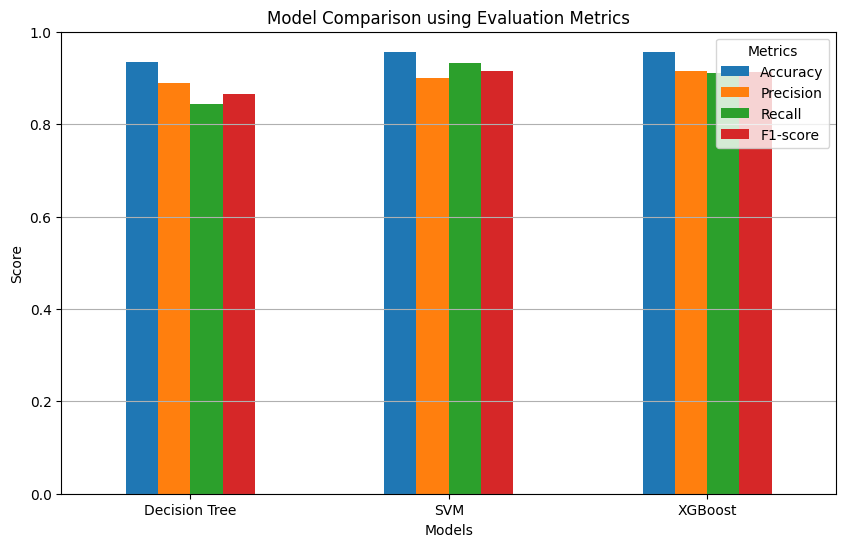

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC

# -------------------------
# Predictions for each model
# -------------------------

# Decision Tree
y_pred_dt = dt_model.predict(X_test_scaled)

# SVM
svm_model_bar = SVC(kernel="rbf", probability=True, random_state=42)
svm_model_bar.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_model_bar.predict(X_test_scaled)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)

# -------------------------
# Calculate metrics
# -------------------------
metrics_data = {
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt)
    ],
    "SVM": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm)
    ],
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb)
    ]
}

metrics_df = pd.DataFrame(
    metrics_data,
    index=["Accuracy", "Precision", "Recall", "F1-score"]
)

# -------------------------
# Bar plot
# -------------------------
ax = metrics_df.T.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison using Evaluation Metrics")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y")
plt.show()